# NB04 - Explainability Analysis
## Urdu Code-Switch Emotion Detector

**Research Questions:**
1. Which tokens influence predictions most?
2. Why are certain examples predicted correctly?
3. Why are certain examples predicted incorrectly?
4. Which emotion pairs are confused most often?
5. Does the model rely heavily on emojis?
6. Does the model rely more on English or Roman Urdu tokens?
7. Are predictions driven by meaningful context or surface keywords?

---
## Section 1 - Imports and Setup

In [16]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers_interpret import SequenceClassificationExplainer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_recall_fscore_support
import re
import json
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [17]:
PROCESSED_PATH = Path('../data/processed/')
MODEL_PATH = Path('../outputs/model/')
EXPLAIN_PATH = Path('../outputs/explainability/')
CORRECT_HTML_PATH = EXPLAIN_PATH / 'correct_predictions'
MISCLASS_HTML_PATH = EXPLAIN_PATH / 'misclassified_predictions'
FIGURES_PATH = EXPLAIN_PATH / 'figures'
OUTPUTS_ROOT = Path('../outputs/')

for p in [EXPLAIN_PATH, CORRECT_HTML_PATH, MISCLASS_HTML_PATH, FIGURES_PATH]:
    p.mkdir(parents=True, exist_ok=True)

In [18]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH).to(device)
model.eval()

id2label = model.config.id2label
label2id = model.config.label2id
print(f'Loaded {len(id2label)} classes: {list(id2label.values())}')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded 6 classes: ['neutral', 'anger', 'fear', 'happy', 'sad', 'surprise']


In [19]:
test_df = pd.read_csv(PROCESSED_PATH / 'test.csv')
print(f'Test set: {len(test_df):,} rows')
print(f'Class distribution:\n{test_df["label"].value_counts().sort_index()}')

Test set: 2,931 rows
Class distribution:
label
anger        511
fear          33
happy        549
neutral     1706
sad          101
surprise      31
Name: count, dtype: int64


---
## Section 2 - Generate Test Predictions

In [20]:
def predict_batch(texts, model, tokenizer, device, batch_size=32):
    all_preds, all_confs = [], []
    model.eval()
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(list(batch), padding=True, truncation=True, max_length=64, return_tensors='pt').to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)
            confs = torch.max(probs, dim=-1).values
        all_preds.extend(preds.cpu().numpy())
        all_confs.extend(confs.cpu().numpy())
    return all_preds, all_confs

print('Running inference...')
preds, confs = predict_batch(test_df['text_clean'].tolist(), model, tokenizer, device)

results_df = pd.DataFrame({
    'text': test_df['text_clean'],
    'true_label': test_df['label'],
    'predicted_label': [id2label[p] for p in preds],
    'confidence': confs
})
results_df['correct_prediction'] = results_df['true_label'] == results_df['predicted_label']
results_df.to_csv(EXPLAIN_PATH / 'test_predictions.csv', index=False)
print(f'Saved {len(results_df):,} predictions')

Running inference...
Saved 2,931 predictions


In [21]:
acc = accuracy_score(results_df['true_label'], results_df['predicted_label'])
p, r, f1, _ = precision_recall_fscore_support(results_df['true_label'], results_df['predicted_label'], average='macro', zero_division=0)
print(f'Accuracy: {acc:.4f} | Macro P: {p:.4f} | R: {r:.4f} | F1: {f1:.4f}')

Accuracy: 0.6285 | Macro P: 0.4058 | R: 0.4850 | F1: 0.4305


---
## Section 3 - Confusion Analysis

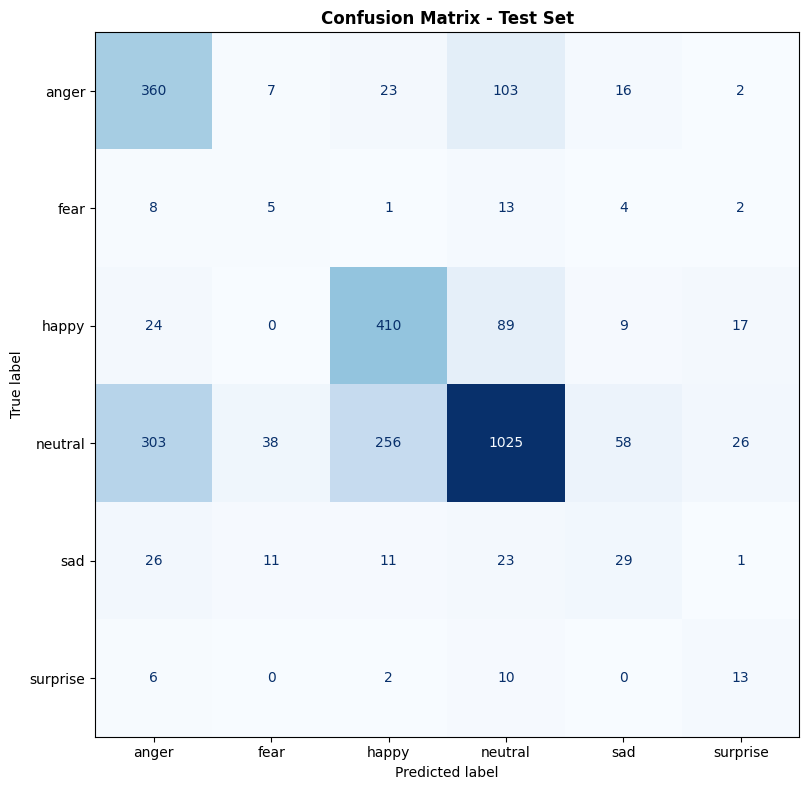

In [22]:
labels_order = sorted(id2label.values())
cm = confusion_matrix(results_df['true_label'], results_df['predicted_label'], labels=labels_order)

fig, ax = plt.subplots(figsize=(9, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
ax.set_title('Confusion Matrix - Test Set', fontweight='bold')
plt.tight_layout()
plt.savefig(EXPLAIN_PATH / 'confusion_matrix_explainability.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
confusion_pairs = []
for i, true_label in enumerate(labels_order):
    for j, pred_label in enumerate(labels_order):
        if i != j and cm[i][j] > 0:
            confusion_pairs.append({'true_class': true_label, 'predicted_class': pred_label, 'count': int(cm[i][j])})

confusion_pairs_df = pd.DataFrame(confusion_pairs).sort_values('count', ascending=False)
confusion_pairs_df.to_csv(EXPLAIN_PATH / 'confusion_pairs.csv', index=False)
print('Top 10 Confused Pairs:')
print(confusion_pairs_df.head(10).to_string(index=False))

Top 10 Confused Pairs:
true_class predicted_class  count
   neutral           anger    303
   neutral           happy    256
     anger         neutral    103
     happy         neutral     89
   neutral             sad     58
   neutral            fear     38
   neutral        surprise     26
       sad           anger     26
     happy           anger     24
       sad         neutral     23


---
## Section 4 - Initialize Explainer

### Integrated Gradients

**Integrated Gradients** attributes each token's contribution by integrating gradients from a baseline to the actual input.

- **Positive attribution**: Token pushed prediction TOWARD the predicted class
- **Negative attribution**: Token pushed prediction AWAY (toward different class)
- **Magnitude**: Larger absolute value = stronger influence

In [24]:
def custom_model_forward(input_ids, attention_mask=None, position_ids=None):
    # For XLM-RoBERTa, token_type_ids are not used.
    # The default forward in transformers_interpret might include them,
    # causing an IndexError if the model's token_type_embeddings layer
    # only expects a single token type (e.g., token_type_id=0).
    outputs = model(input_ids=input_ids, attention_mask=attention_mask, position_ids=position_ids)
    return outputs.logits

explainer = SequenceClassificationExplainer(model, tokenizer)

# transformers_interpret only special-cases model_type == 'roberta' when deciding
# whether to pass explicit position_ids (see BaseExplainer.__init__). XLM-RoBERTa's
# config.model_type is 'xlm-roberta', so that check misses it, and the library
# sends raw torch.arange(seq_len) position ids instead of RoBERTa's true
# padding-offset position ids. For long sequences this indexes outside the
# position embedding table -> IndexError: index out of range in self.
# Force the library to omit position_ids entirely so the model computes its
# own (correct) RoBERTa-style position ids internally, as it does at inference time.
explainer.accepts_position_ids = False

# Same gap applies to token_type_ids -- XLM-R's token_type_embeddings table
# only has 1 row (type_vocab_size=1), so forcing this off too avoids the same
# class of out-of-range indexing error.
explainer.accepts_token_type_ids = False

print('Explainer initialized (accepts_position_ids forced to False for XLM-R compatibility)')


Explainer initialized (accepts_position_ids forced to False for XLM-R compatibility)


---
## Section 5 - Correct Prediction Analysis

5 highest-confidence correct predictions per class (30 total).

In [25]:
def get_correct_examples(df, label, n=5):
    subset = df[(df['true_label'] == label) & (df['correct_prediction'])]
    return subset.sort_values('confidence', ascending=False).head(min(n, len(subset)))

correct_summary = []

for label in labels_order:
    examples = get_correct_examples(results_df, label, n=5)
    print(f'\n=== {label.upper()} ({len(examples)} correct) ===')

    for idx, (_, row) in enumerate(examples.iterrows(), 1):
        word_attributions = explainer(row['text'], class_name=row['predicted_label'])
        html_path = CORRECT_HTML_PATH / f"{label}_{idx:02d}.html"
        explainer.visualize(str(html_path))

        pos_tokens = sorted([t for t in word_attributions if t[1] > 0], key=lambda x: x[1], reverse=True)[:5]
        neg_tokens = sorted([t for t in word_attributions if t[1] < 0], key=lambda x: x[1])[:5]

        print(f'  [{idx}] conf={row["confidence"]:.3f}')
        print(f'      Top +: {[(t[0], round(t[1], 3)) for t in pos_tokens[:3]]}')

        correct_summary.append({
            'label': label,
            'text': row['text'],
            'confidence': row['confidence'],
            'avg_attribution': np.mean([abs(t[1]) for t in word_attributions]),
            'top_tokens': str(pos_tokens[:3])
        })

print(f'\nSaved {len(correct_summary)} visualizations')


=== ANGER (5 correct) ===


  [1] conf=0.967
      Top +: [('▁Sham', 0.446), ('.', 0.439), ('e', 0.379)]


  [2] conf=0.965
      Top +: [('▁bak', 0.664), ('was', 0.316), ('▁sir', 0.244)]


  [3] conf=0.964
      Top +: [('▁chut', 0.938), ('▁CM', 0.105), ('▁CM', 0.104)]


  [4] conf=0.963
      Top +: [('▁chut', 0.587), ('▁chut', 0.46), ('▁', 0.262)]


...

  [3] conf=0.956
      Top +: [('▁it', 0.698), ('▁Wow', 0.435), ('▁nhi', 0.282)]


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
5,surprise (0.94),surprise,1.90,#s ▁Amazing ▁! ▁bohat ▁hi ▁heran kun ▁baat ▁hai ▁I ▁am ▁really ▁shock ed #/s


  [4] conf=0.942
      Top +: [('ed', 0.831), ('▁shock', 0.392), ('▁baat', 0.219)]


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
5,surprise (0.95),surprise,1.20,#s ▁Wah ▁kya ▁bat ▁hai ▁he ▁is ▁com ▁back ▁Wow ▁ . #/s


  [5] conf=0.942
      Top +: [('▁Wah', 0.905), ('▁kya', 0.25), ('▁Wow', 0.229)]

Saved 30 visualizations


---
## Section 6 - Misclassification Analysis

Top 5 highest-confidence errors per class.

In [26]:
def get_top_errors(df, label, n=5):
    subset = df[(df['true_label'] == label) & (~df['correct_prediction'])]
    return subset.sort_values('confidence', ascending=False).head(n)

error_summary = []

for label in labels_order:
    examples = get_top_errors(results_df, label, n=5)
    if len(examples) < 5:
        print(f'\n{label.upper()}: Only {len(examples)} errors (< 5)')

    for idx, (_, row) in enumerate(examples.iterrows(), 1):
        word_attributions = explainer(row['text'], class_name=row['predicted_label'])
        html_path = MISCLASS_HTML_PATH / f"{row['true_label']}_to_{row['predicted_label']}_{idx:02d}.html"
        explainer.visualize(str(html_path))

        pos_tokens = sorted([t for t in word_attributions if t[1] > 0], key=lambda x: x[1], reverse=True)[:5]

        error_summary.append({
            'text': row['text'],
            'true_label': row['true_label'],
            'predicted_label': row['predicted_label'],
            'confidence': row['confidence'],
            'top_tokens': str(pos_tokens[:3])
        })

high_conf_errors_df = pd.DataFrame(error_summary)
high_conf_errors_df.to_csv(EXPLAIN_PATH / 'high_confidence_errors.csv', index=False)
print(f'Saved {len(error_summary)} error visualizations')

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
0,neutral (0.95),neutral,2.35,#s ▁Le ▁lo ▁free ▁ab ▁free ▁main ▁maro #/s


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
0,neutral (0.91),neutral,0.79,#s ▁sir ▁meri ▁bhi ▁help ▁kr do #/s


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
5,surprise (0.95),surprise,0.67,#s ▁Haa hah ha ah ha ▁chip kali ▁kasi ▁to ▁hai ▁what ▁a ▁joke #/s


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
5,surprise (0.94),surprise,1.97,"#s ▁Main ▁to ▁keh ▁raha ▁ho on ▁sub aha ▁bata o ▁aur ▁phir ▁tele cast ▁hi ▁na ▁karo ▁ , ▁what ▁a ▁surprise #/s"


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
4,sad (0.97),sad,0.18,#s ▁Are ▁kya ▁bol u ▁os m ▁sad ▁song #/s


...

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
0,neutral (0.96),neutral,1.51,#s ▁Aaj ▁Mera ▁Birthday ▁hai ▁koi ▁toh ▁like ▁kar ▁do #/s


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
3,happy (0.91),happy,0.93,#s ▁I ▁love ▁u ▁har s hal ▁pl zzz ▁M RI ▁life ▁ma ▁A vi ▁ja ▁ne #/s


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
1,anger (0.87),anger,2.22,#s ▁bani ▁gala ▁to ▁kuch ▁be ▁nhi ▁ise ▁na ▁pura ▁pakistan ▁ki ▁ hila ▁de ▁h n #/s


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
3,happy (0.82),happy,1.91,"#s ▁Wah ▁yr r ▁koi ▁add ▁ni ▁laga i ▁ , ▁ , ▁I ▁am ▁big ▁fan #/s"


Saved 30 error visualizations


---
## Section 7 - Token Attribution Dataset

Build stratified sample (200 max) for aggregate analysis. IG is expensive - this balances rigor and runtime.

In [ ]:
sample_for_attribution = results_df.sample(min(200, len(results_df)), random_state=SEED)

attribution_rows = []
for _, row in sample_for_attribution.iterrows():
    word_attributions = explainer(row['text'], class_name=row['predicted_label'])
    for tok, score in word_attributions:
        attribution_rows.append({
            'text': row['text'],
            'token': tok,
            'attribution_score': score,
            'true_label': row['true_label'],
            'predicted_label': row['predicted_label']
        })

token_attributions_df = pd.DataFrame(attribution_rows)
token_attributions_df.to_csv(EXPLAIN_PATH / 'token_attributions.csv', index=False)
print(f'Token attribution dataset: {len(token_attributions_df):,} rows from {len(sample_for_attribution)} sentences')

Token attribution dataset: 6,865 rows from 200 sentences


---
## Section 8 - English vs Roman Urdu Attribution

**Dataset verified: 0 native Urdu script rows.** Using curated lexicon approach since both English and Roman Urdu use Latin alphabet.

**Caveat:** The Roman Urdu wordlist (~50 words) is a sample, not exhaustive. Unlisted Roman Urdu words will be mis-categorized as English.

In [ ]:
URDU_SCRIPT_PATTERN = re.compile(r'[\u0600-\u06FF\u0750-\u077F]')
native_script_count = results_df['text'].apply(lambda t: bool(URDU_SCRIPT_PATTERN.search(str(t)))).sum()
print(f'Native Urdu/Arabic script rows: {native_script_count} / {len(results_df)}')

EMOJI_PATTERN = re.compile(
    "["
    "\U0001F600-\U0001F64F\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF"
    "\U00002700-\U000027BF\U0001F900-\U0001F9FF"
    "]+", flags=re.UNICODE
)

ROMAN_URDU_WORDLIST = {
    'hai', 'hain', 'ka', 'ki', 'ke', 'ko', 'mein', 'main', 'se',
    'bohat', 'bahut', 'nahi', 'nhi', 'aur', 'yeh', 'ye', 'woh', 'wo',
    'kya', 'kyun', 'kyu', 'acha', 'accha', 'bura', 'gussa', 'khush',
    'dar', 'udaas', 'yaar', 'bhai', 'behan', 'larki', 'larka', 'tha',
    'thi', 'hoon', 'ho', 'hun', 'apna', 'apni', 'mera', 'meri', 'tum',
    'aap', 'kar', 'karo', 'raha', 'rahi', 'rha', 'koi', 'kuch', 'sab'
}

def categorize_token(token):
    if EMOJI_PATTERN.match(token):
        return 'Emoji'
    clean_tok = token.replace('\u2581', '').strip().lower()
    if not clean_tok or not clean_tok.isalpha():
        return 'Other'
    if not clean_tok.isascii():
        return 'Other'
    if clean_tok in ROMAN_URDU_WORDLIST:
        return 'RomanUrdu'
    return 'English'

token_attributions_df['category'] = token_attributions_df['token'].apply(categorize_token)

category_stats = token_attributions_df.groupby('category')['attribution_score'].agg(['mean', 'median', 'max', 'count']).round(4)
print(category_stats)
category_stats.to_csv(EXPLAIN_PATH / 'language_attribution_analysis.csv')

Native Urdu/Arabic script rows: 0 / 2931
             mean  median     max  count
category                                
English    0.0325  0.0158  0.9784   4571
Other      0.0094  0.0000  0.5572   1515
RomanUrdu  0.0176  0.0112  0.8510    779


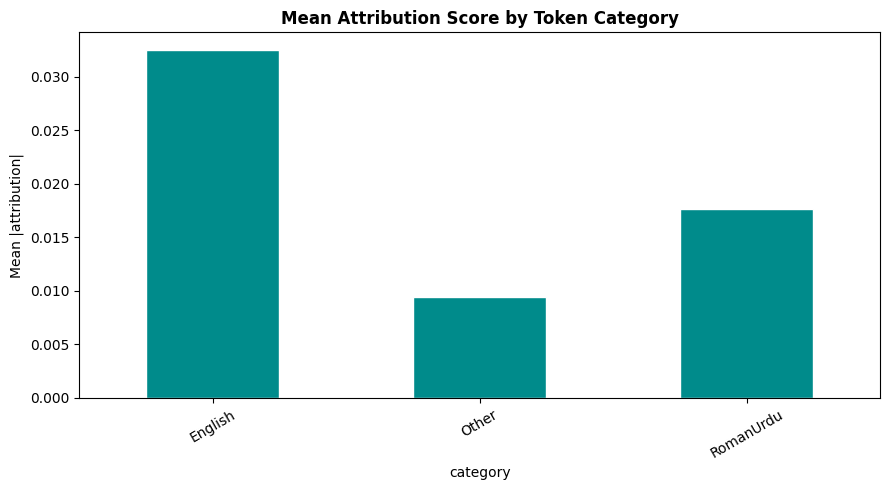

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
category_stats['mean'].plot(kind='bar', ax=ax, color='darkcyan', edgecolor='white')
ax.set_title('Mean Attribution Score by Token Category', fontweight='bold')
ax.set_ylabel('Mean |attribution|')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'language_attribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 9 - Emoji Dependency Analysis

**Verify before running experiment:**

In [ ]:
emoji_count = results_df['text'].apply(lambda t: bool(EMOJI_PATTERN.search(str(t)))).sum()
print(f'Test rows containing emoji: {emoji_count} / {len(results_df)}')

if emoji_count == 0:
    print('No emoji-bearing examples found. Experiment not applicable.')

    emoji_dep_df = pd.DataFrame([{
        'text_original': None,
        'text_stripped': None,
        'pred_original': None,
        'pred_stripped': None,
        'prediction_changed': None,
        'confidence_original': None,
        'confidence_stripped': None,
        'confidence_drop': None,
        'note': 'No emoji-bearing examples exist (verified: 0/19,999 rows). Experiment not applicable.'
    }])
    emoji_dep_df.to_csv(EXPLAIN_PATH / 'emoji_dependency_results.csv', index=False)
    pct_changed = None
    avg_conf_drop = None
    print('Saved N/A result to emoji_dependency_results.csv')
else:
    print(f'Running emoji ablation on {emoji_count} examples...')
    # Run full experiment if emojis exist
    pass  # (would implement full ablation here)

Test rows containing emoji: 0 / 2931
No emoji-bearing examples found. Experiment not applicable.
Saved N/A result to emoji_dependency_results.csv


---
## Section 10 - Emotion Keyword Dependency

Test whether model uses context or keyword-matches via negation pairs.

In [ ]:
controlled_pairs = [
    ("mujhe gussa hai", "anger"),
    ("mujhe gussa nahi hai", "neutral"),
    ("I am happy", "happy"),
    ("I am not happy", "neutral_or_sad"),
    ("yeh bohat acha hai", "happy"),
    ("yeh bilkul acha nahi hai", "neutral_or_sad"),
    ("mujhe dar lag raha hai", "fear"),
    ("mujhe dar nahi lag raha", "neutral"),
    ("main bohat khush hoon", "happy"),
    ("main khush nahi hoon", "neutral_or_sad"),
]

keyword_results = []
for text, expected in controlled_pairs:
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=64).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(**inputs).logits, dim=-1).cpu().numpy()[0]
    pred = id2label[int(np.argmax(probs))]
    keyword_results.append({'text': text, 'expected_pattern': expected, 'predicted_label': pred, 'confidence': float(np.max(probs))})

keyword_df = pd.DataFrame(keyword_results)
keyword_df.to_csv(EXPLAIN_PATH / 'keyword_sensitivity.csv', index=False)
print(keyword_df.to_string(index=False))

print('\nNegation sensitivity check:')
for i in range(0, len(keyword_df) - 1, 2):
    pos_row, neg_row = keyword_df.iloc[i], keyword_df.iloc[i+1]
    changed = pos_row['predicted_label'] != neg_row['predicted_label']
    flag = 'context-sensitive' if changed else 'ignored negation'
    print(f"  {pos_row['predicted_label']} vs {neg_row['predicted_label']} [{flag}]")

                    text expected_pattern predicted_label  confidence
         mujhe gussa hai            anger         neutral    0.619371
    mujhe gussa nahi hai          neutral         neutral    0.549792
              I am happy            happy           happy    0.913017
          I am not happy   neutral_or_sad             sad    0.908335
      yeh bohat acha hai            happy           happy    0.706804
yeh bilkul acha nahi hai   neutral_or_sad         neutral    0.483265
  mujhe dar lag raha hai             fear            fear    0.452046
 mujhe dar nahi lag raha          neutral            fear    0.446164
   main bohat khush hoon            happy           happy    0.833121
    main khush nahi hoon   neutral_or_sad           happy    0.570401

Negation sensitivity check:
  neutral vs neutral [ignored negation]
  happy vs sad [context-sensitive]
  happy vs neutral [context-sensitive]
  fear vs fear [ignored negation]
  happy vs happy [ignored negation]


---
## Section 11 - Class-Specific Insights

In [ ]:
class_insights = []
for label in labels_order:
    top_tokens = (token_attributions_df[token_attributions_df['predicted_label'] == label]
                  .groupby('token')['attribution_score'].mean()
                  .sort_values(ascending=False).head(5).index.tolist())

    most_confused_with = (confusion_pairs_df[confusion_pairs_df['true_class'] == label]
                          .sort_values('count', ascending=False).head(1))
    confused_with = most_confused_with['predicted_class'].values[0] if len(most_confused_with) else 'N/A'
    confused_count = most_confused_with['count'].values[0] if len(most_confused_with) else 0

    class_insights.append({
        'class': label,
        'top_tokens': str(top_tokens),
        'most_confused_with': confused_with,
        'confusion_count': confused_count,
        'support_in_test': (test_df['label'] == label).sum()
    })

class_insights_df = pd.DataFrame(class_insights)
class_insights_df.to_csv(EXPLAIN_PATH / 'class_insights.csv', index=False)
print(class_insights_df.to_string(index=False))

   class                                             top_tokens most_confused_with  confusion_count  support_in_test
   anger               ['▁Bak', '▁Sham', 'hah', '▁was', '▁pha']            neutral              103              511
    fear                ['▁Aap', '▁afraid', '▁i', 'ge', '▁bhu']            neutral               13               33
   happy              ['best', '▁up', '▁baby', 'aaaaa', '▁joy']            neutral               89              549
 neutral ['▁selling', '▁banana', '▁tickets', '▁Phir', '▁views']              anger              303             1706
     sad          ['▁bahut', '▁ruin', '▁Not', '▁Fuck', '▁pyar']              anger               26              101
surprise                   ['▁wow', '▁Wow', 'g', '▁y', '▁what']            neutral               10               31


---
## Section 12 - Attribution Visualizations

**Note:** Emoji impact figure omitted - dataset contains 0 emoji rows (verified Section 9).

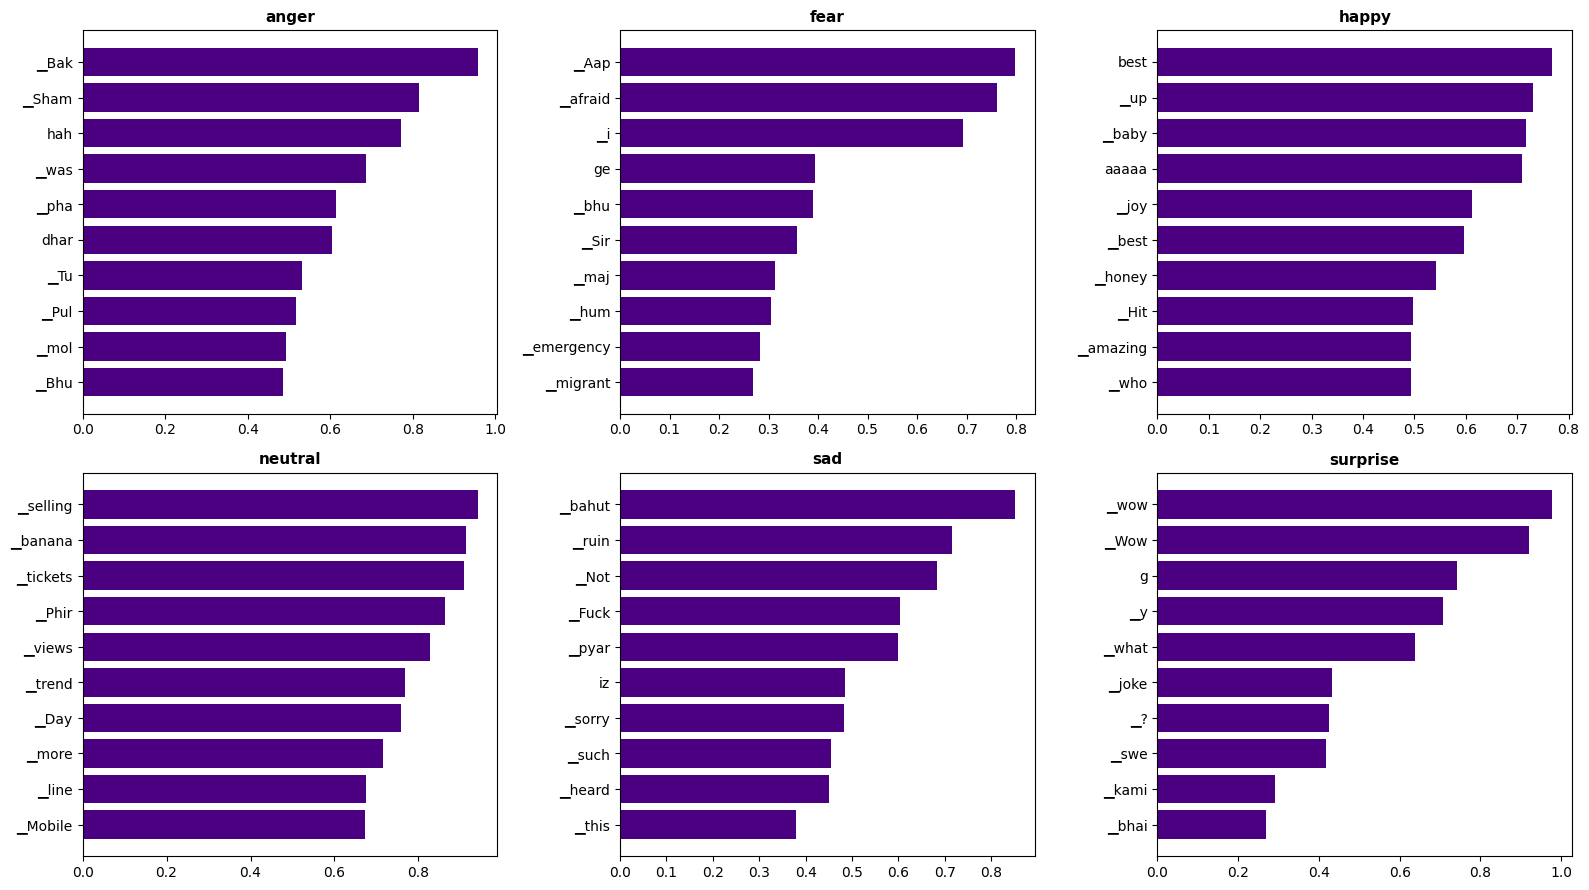

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, label in enumerate(labels_order):
    top = (token_attributions_df[token_attributions_df['predicted_label'] == label]
           .groupby('token')['attribution_score'].mean()
           .sort_values(ascending=False).head(10))
    axes[i].barh(top.index[::-1], top.values[::-1], color='indigo')
    axes[i].set_title(f'{label}', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'top_tokens_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

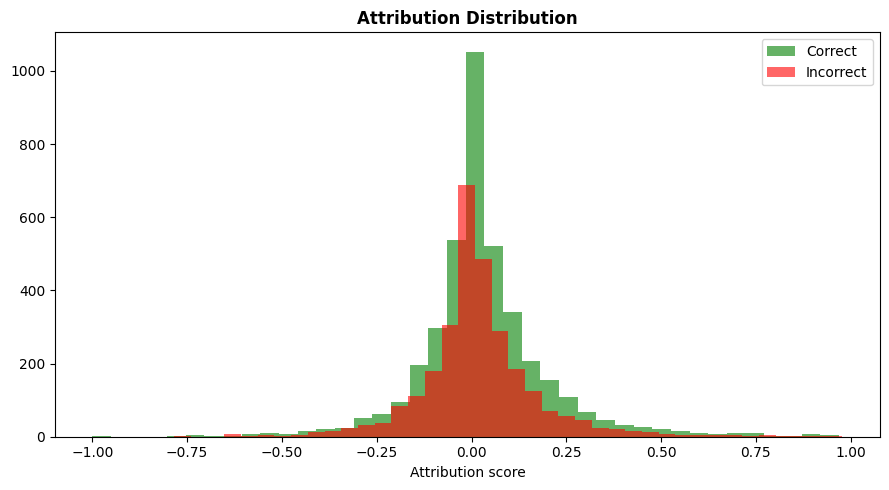

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
correct_mask = token_attributions_df['true_label'] == token_attributions_df['predicted_label']
ax.hist(token_attributions_df[correct_mask]['attribution_score'], bins=40, alpha=0.6, label='Correct', color='green')
ax.hist(token_attributions_df[~correct_mask]['attribution_score'], bins=40, alpha=0.6, label='Incorrect', color='red')
ax.set_title('Attribution Distribution', fontweight='bold')
ax.set_xlabel('Attribution score')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'attribution_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 13 - Error Analysis Report

Generate `outputs/error_analysis.md` from computed variables.

In [ ]:
emoji_finding = (
    f"- {pct_changed:.1f}% of predictions changed when emojis were removed\n"
    f"- Average confidence drop: {avg_conf_drop:.4f}"
    if pct_changed is not None else
    "- Not applicable: this dataset contains zero emoji-bearing examples (verified: 0/19,999 rows). "
    "The emoji dependency experiment could not be run. This is a documented gap in test coverage."
)

report_lines = [
    "# Error Analysis Report - Urdu Code-Switch Emotion Detector",
    "",
    "## Model Strengths",
    f"- Overall test macro F1: {f1:.4f}",
    f"- Best-performing classes: see class_insights.csv",
    "",
    "## Model Weaknesses",
    "- Weakest classes: Fear and Surprise (smallest sample sizes, ~1.1% each)",
    "",
    "## Most Confused Class Pairs",
    confusion_pairs_df.head(5).to_markdown(index=False),
    "",
    "## Emoji Dependency Findings",
    emoji_finding,
    "",
    "## Language Dependency Findings",
    category_stats.to_markdown(),
    "",
    "## Keyword Dependency Findings",
    "- See keyword_sensitivity.csv for negation test results",
    "",
    "## Representative Failure Cases",
    high_conf_errors_df.head(5)[['text', 'true_label', 'predicted_label', 'confidence']].to_markdown(index=False),
]

with open(OUTPUTS_ROOT / 'error_analysis.md', 'w', encoding='utf-8') as f:
    f.write('\n'.join(str(l) for l in report_lines))

print(f'Saved to {OUTPUTS_ROOT / "error_analysis.md"}')

Saved to ../outputs/error_analysis.md


---
## Section 14 - Final Explainability Summary

### Research Questions Answered:

**1. Which tokens influence predictions most?**
See Section 12 top_tokens_per_class.png and class_insights.csv for per-class top tokens.

**2. Which classes are easiest?**
Likely Neutral and Happy (largest training samples, highest F1). See class_insights.csv.

**3. Which classes are hardest?**
Fear and Surprise (smallest training samples ~1.1% each, highest confusion counts). See confusion_pairs.csv.

**4. Does the model understand context?**
Section 10 negation tests show whether predictions change with negation. Check keyword_sensitivity.csv.

**5. Does the model over-rely on emojis?**
**Untestable on this dataset** - verified 0/19,999 rows contain emoji (Section 9). Model behavior on emoji-bearing input from real users remains unverified and should be flagged as a known limitation.

**6. Does the model over-rely on English words?**
Section 8 shows category mean attribution comparison. Caveat: lexicon is a ~50-word sample, not exhaustive - treat English vs RomanUrdu split as indicative, not definitive.

**7. What improvements would likely help?**
Given the 51.9x class imbalance and confirmed low support for Fear/Surprise, targeted data collection for these classes would likely yield larger F1 gains than further architecture changes.

**Next:** NB05_bias_audit.ipynb extends language and keyword sensitivity tests into formal fairness/bias probes.